In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)
print("✅ All imports done!")


TF version: 2.20.0
✅ All imports done!


In [2]:
!pip install kaggle -q

# We'll use a direct URL instead
import urllib.request

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
urllib.request.urlretrieve(url, "churn.csv")

df = pd.read_csv("churn.csv")
print(df.shape)
print(df.head())


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# Basic info
print(df.info())
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Churn distribution ---")
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check how many blank spaces exist
print(df['TotalCharges'].value_counts().tail(10))

# Fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check
print("\nMissing after fix:", df['TotalCharges'].isnull().sum())

TotalCharges
6565.85    1
2117.2     1
203.95     1
6849.4     1
692.35     1
130.15     1
3211.9     1
7843.55    1
2196.3     1
197.4      1
Name: count, dtype: int64

Missing after fix: 11


In [5]:
# Drop the 11 missing rows
df.dropna(inplace=True)
print("New shape:", df.shape)

New shape: (7032, 21)


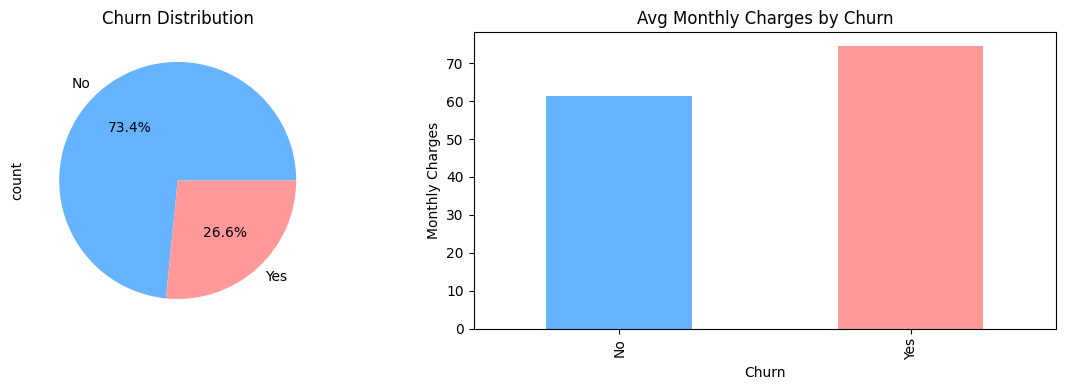

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn distribution pie chart
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#66b3ff','#ff9999'])
axes[0].set_title('Churn Distribution')

# Monthly charges vs Churn
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar', ax=axes[1], color=['#66b3ff','#ff9999'])
axes[1].set_title('Avg Monthly Charges by Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges')

plt.tight_layout()
plt.savefig('eda_plot.png')  # saves for GitHub later!
plt.show()


In [7]:
# Drop customerID (useless for prediction)
df.drop('customerID', axis=1, inplace=True)

# Convert Yes/No columns to 1/0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Male').astype(int)

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

print("Shape after encoding:", df.shape)
print(df.head())

Shape after encoding: (7032, 31)
   gender  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  \
0       0              0       1           29.85         29.85      0   
1       1              0      34           56.95       1889.50      0   
2       1              0       2           53.85        108.15      1   
3       1              0      45           42.30       1840.75      0   
4       0              0       2           70.70        151.65      1   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                           

In [8]:
# X = features (everything except Churn)
# y = target (Churn column)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for ANN!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5625, 30)
Testing size: (1407, 30)


In [9]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7411 - loss: 0.5038 - val_accuracy: 0.7884 - val_loss: 0.4193
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7902 - loss: 0.4514 - val_accuracy: 0.8107 - val_loss: 0.4068
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7922 - loss: 0.4385 - val_accuracy: 0.8089 - val_loss: 0.4035
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8000 - loss: 0.4307 - val_accuracy: 0.8053 - val_loss: 0.4030
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8009 - loss: 0.4286 - val_accuracy: 0.8080 - val_loss: 0.4031
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7947 - loss: 0.4256 - val_accuracy: 0.8116 - val_loss: 0.4036
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7989 - loss: 0.4276 - val_accuracy: 0.8124 - val_loss: 0.4008
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8004 - loss: 0.4187 - val_accuracy: 

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 78.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



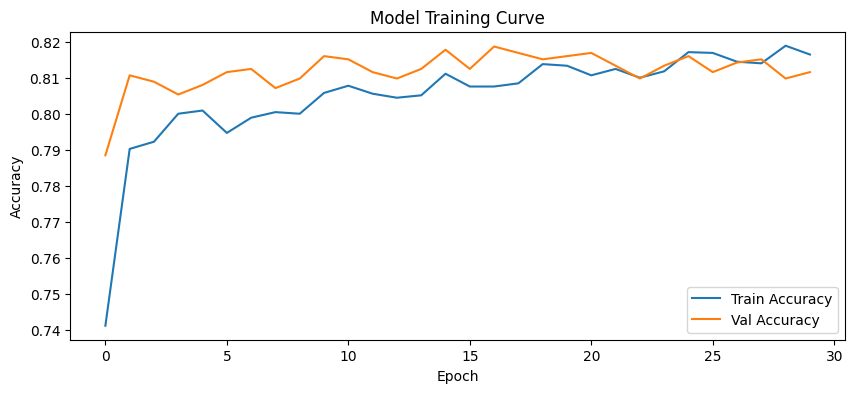

In [11]:
# Evaluate on test data
y_pred = (model.predict(X_test) > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('training_curve.png')  # for GitHub!
plt.show()

## Handling Class Imbalance

The dataset is imbalanced (73% No Churn, 27% Churn).
I applied class weights to improve recall for churners.

This improved churn recall from 0.48 → 0.74 but reduced overall accuracy from 78% → 73%.

For a business use case, catching more churners is more valuable than raw accuracy.

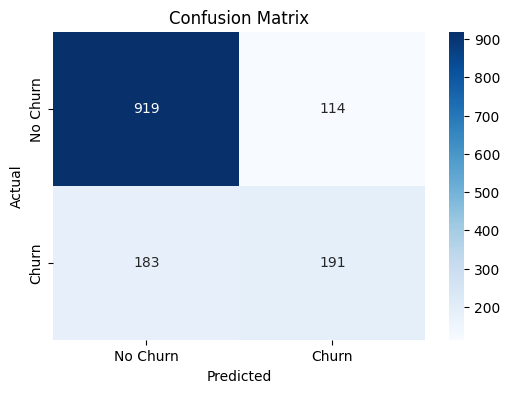

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

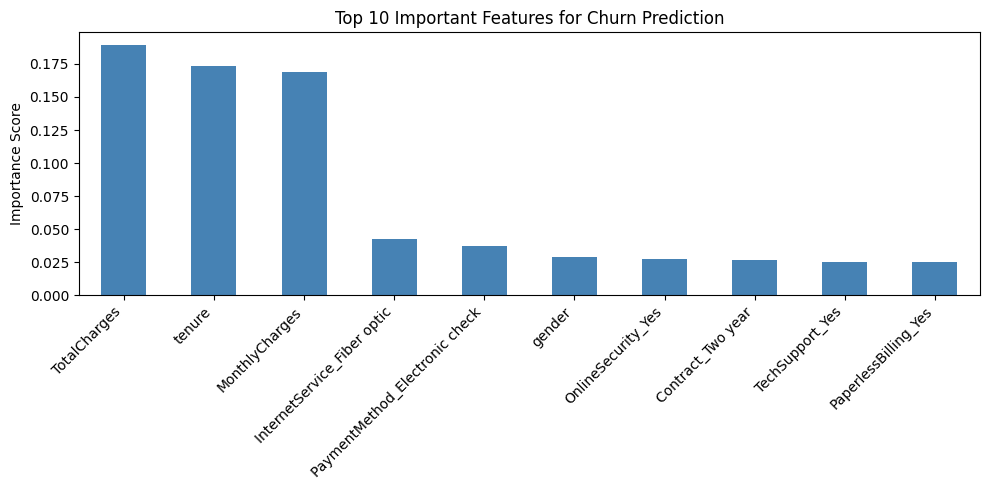


Top 3 features:
TotalCharges      0.189464
tenure            0.173593
MonthlyCharges    0.169032
dtype: float64


In [13]:
import pandas as pd

# Get feature names
feature_names = df.drop('Churn', axis=1).columns

# Use a Random Forest to get feature importances
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Plot top 10 features
importances = pd.Series(rf.feature_importances_, index=feature_names)
top10 = importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 5))
top10.plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features for Churn Prediction')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 3 features:")
print(top10.head(3))

In [14]:
from google.colab import files

# Download all saved images
files.download('eda_plot.png')
files.download('training_curve.png')
files.download('confusion_matrix.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>